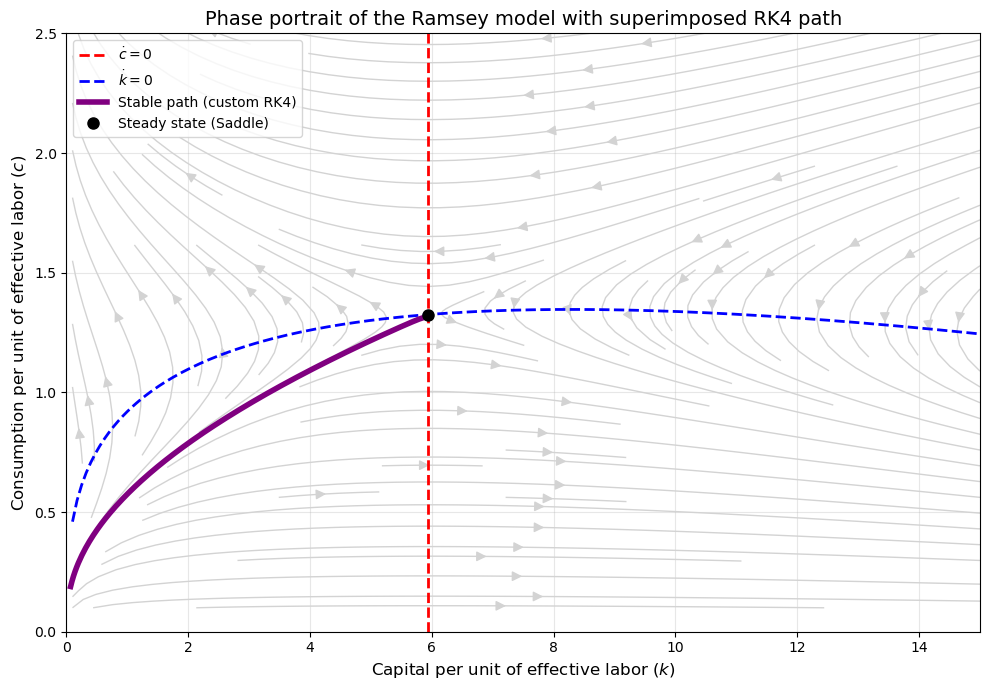

In [3]:
import numpy as np
import matplotlib.pyplot as plt

'''
A few words about the model:

The Ramsey-Cass-Koopmans model is based on two dynamic equations describing
households deciding on the amount of invested capital and producers maximizing
the production of goods
'''


# parameters
alpha = 0.33   # capital share
delta = 0.05   # depreciation rate
rho = 0.02     # time preference rate
theta = 1.5    # risk aversion
n = 0.01       # population growth
g = 0.02       # technological progress

# steady state
k_star = (alpha / (delta + rho + theta * g)) ** (1 / (1 - alpha))
c_star = k_star**alpha - (n + g + delta) * k_star

# differential equations with reversed time
def ramsey_backwards(t, state):
    k, c = state
    k = max(k, 1e-5)
    c = max(c, 1e-5)
    
    dk_dt = k**alpha - c - (n + g + delta) * k
    dc_dt = c * (1 / theta) * (alpha * k**(alpha - 1) - delta - rho - theta * g)
    
    return np.array([-dk_dt, -dc_dt])

# RK4 method 
def rk4(f, t0, y0, h, steps):
    t = t0
    y = np.array(y0, dtype=float)
    ts = [t]
    ys = [y.copy()]
    
    for _ in range(steps):
        k1 = h * f(t, y)
        k2 = h * f(t + h/2, y + k1/2)
        k3 = h * f(t + h/2, y + k2/2)
        k4 = h * f(t + h, y + k3)
        
        y_next = y + (k1 + 2*k2 + 2*k3 + k4) / 6
        
        # protection against solution in negative numbers 
        if y_next[0] < 0.05 or y_next[1] < 0.05:
            break
            
        y = y_next
        t += h
        
        ts.append(t)
        ys.append(y.copy())
        
    return np.array(ts), np.array(ys)

# RK4 algorithm
epsilon = 0.01
y0 = [k_star - epsilon, c_star - epsilon]
h = 0.1  # Smaller time step for greater precision
t_end = 100
n_steps = int(t_end / h)

t_rk4, y_rk4 = rk4(ramsey_backwards, 0, y0, h, n_steps)

k_path = y_rk4[:, 0][::-1]
c_path = y_rk4[:, 1][::-1]

# vector field with superimposed solution 
plt.figure(figsize=(10, 7))

k_vals_grid = np.linspace(0.1, 15, 200)
c_vals_grid = np.linspace(0.1, 3, 200)
K, C = np.meshgrid(k_vals_grid, c_vals_grid)

dK_dt = K**alpha - C - (n + g + delta) * K
dC_dt = C * (1 / theta) * (alpha * K**(alpha - 1) - delta - rho - theta * g)

plt.streamplot(K, C, dK_dt, dC_dt, color='lightgray', linewidth=1, density=1.5, arrowsize=1.5)

plt.axvline(x=k_star, color='red', linestyle='--', linewidth=2, label=r'$\dot{c} = 0$')
c_isocline = k_vals_grid**alpha - (n + g + delta) * k_vals_grid
plt.plot(k_vals_grid, c_isocline, color='blue', linestyle='--', linewidth=2, label=r'$\dot{k} = 0$')

# path from RK4
plt.plot(k_path, c_path, color='purple', linewidth=4, label='Stable path (custom RK4)')

# stationary point 
plt.plot(k_star, c_star, 'ko', markersize=8, label='Steady state (Saddle)')

plt.xlim(0, 15)
plt.ylim(0, 2.5)
plt.title('Phase portrait of the Ramsey model with superimposed RK4 path', fontsize=14)
plt.xlabel('Capital per unit of effective labor ($k$)', fontsize=12)
plt.ylabel('Consumption per unit of effective labor ($c$)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The red vertical line represents the level of capital at which the optimal consumption path is constant, while the blue line represents the optimal equilibrium in an economy where the entire output, net of consumption, is just sufficient to cover replacement investment. According to the theory presented in economics textbooks, the vector field is divided into four quadrants representing unbalanced levels of capital and consumption. The black dot represents the saddle point, while the purple line is the stable and only economically admissible trajectory.

As for the numerical method used, it is the standard Runge–Kutta method. However, it was applied with time reversed. This procedure was necessary because the saddle point is highly sensitive to initial conditions; applying standard forward integration would lead to numerical instability and a rapid accumulation of error.